<a href="https://colab.research.google.com/github/lenmecc/miniature-enigma/blob/main/secuenciador_V9_3_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Esta version contiene fecha de finalizacion de la secuenia + indicador si es critico

=== PASO 1: CARGA DE DATOS ===
Por favor sube el extracto de órdenes del ERP (Excel)...


Saving Reporte de Cortos_04.06.18.30_doblez.xlsx to Reporte de Cortos_04.06.18.30_doblez.xlsx

Por favor sube el catálogo 'Prioridades_Clientes.xlsx'...


Saving Prioridades_Clientes.xlsx.xlsx to Prioridades_Clientes.xlsx.xlsx

Por favor sube el historial de máquinas (Excel con 'Numero de Parte' y 'Maquina')...


Saving Produccion tablet083627_30JUL_P1.xlsx to Produccion tablet083627_30JUL_P1.xlsx

¿Hay alguna máquina CAÍDA, SIN OPERADOR o en MANTENIMIENTO?
Escribe sus nombres separados por coma (ej. Dobladora 1, Prensa A) o presiona ENTER si todas operan normal: TB09-LVD


Por favor sube el listado de Productos Estrella/VIP (Excel con columna 'Producto Terminado')...


Saving Criticos_WK24.xlsx to Criticos_WK24.xlsx
[INFO] Se cargaron 65 productos con prioridad alta.

=== ANALIZANDO HISTORIAL DE MÁQUINAS ===
[ALERTA OPERATIVA] Descartando máquinas caídas: ['TB09-LVD']
El sistema re-ruteará el trabajo a las máquinas de respaldo (Opción B)...


...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


[INFO] Se exportó el archivo de auditoría con 4397 órdenes bloqueadas: Ordenes_Bloqueadas_Auditoria.xlsx

Datos listos: 515 órdenes viables para programar.

=== PASO 2: OPTIMIZANDO SECUENCIA EN PARALELO (ATCS POR MÁQUINA) ===


/tmp/ipykernel_2139/4214911569.py:230: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[12.5 22.5 22.5 22.5 22.5 22.5 22.5 22.5 22.5 22.5 22.5 22.5 12.5 22.5
 12.5 12.5 22.5 22.5 22.5 22.5 22.5 22.5 22.5 22.5 22.5 22.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_modelo.loc[mask_pt_prio, 'prioridad'] = df_modelo.loc[mask_pt_prio, 'prioridad'] * FACTOR_BOOST



=== PASO 3: GENERANDO GANTT POR MÁQUINA (PRÓXIMAS 8 HORAS) ===


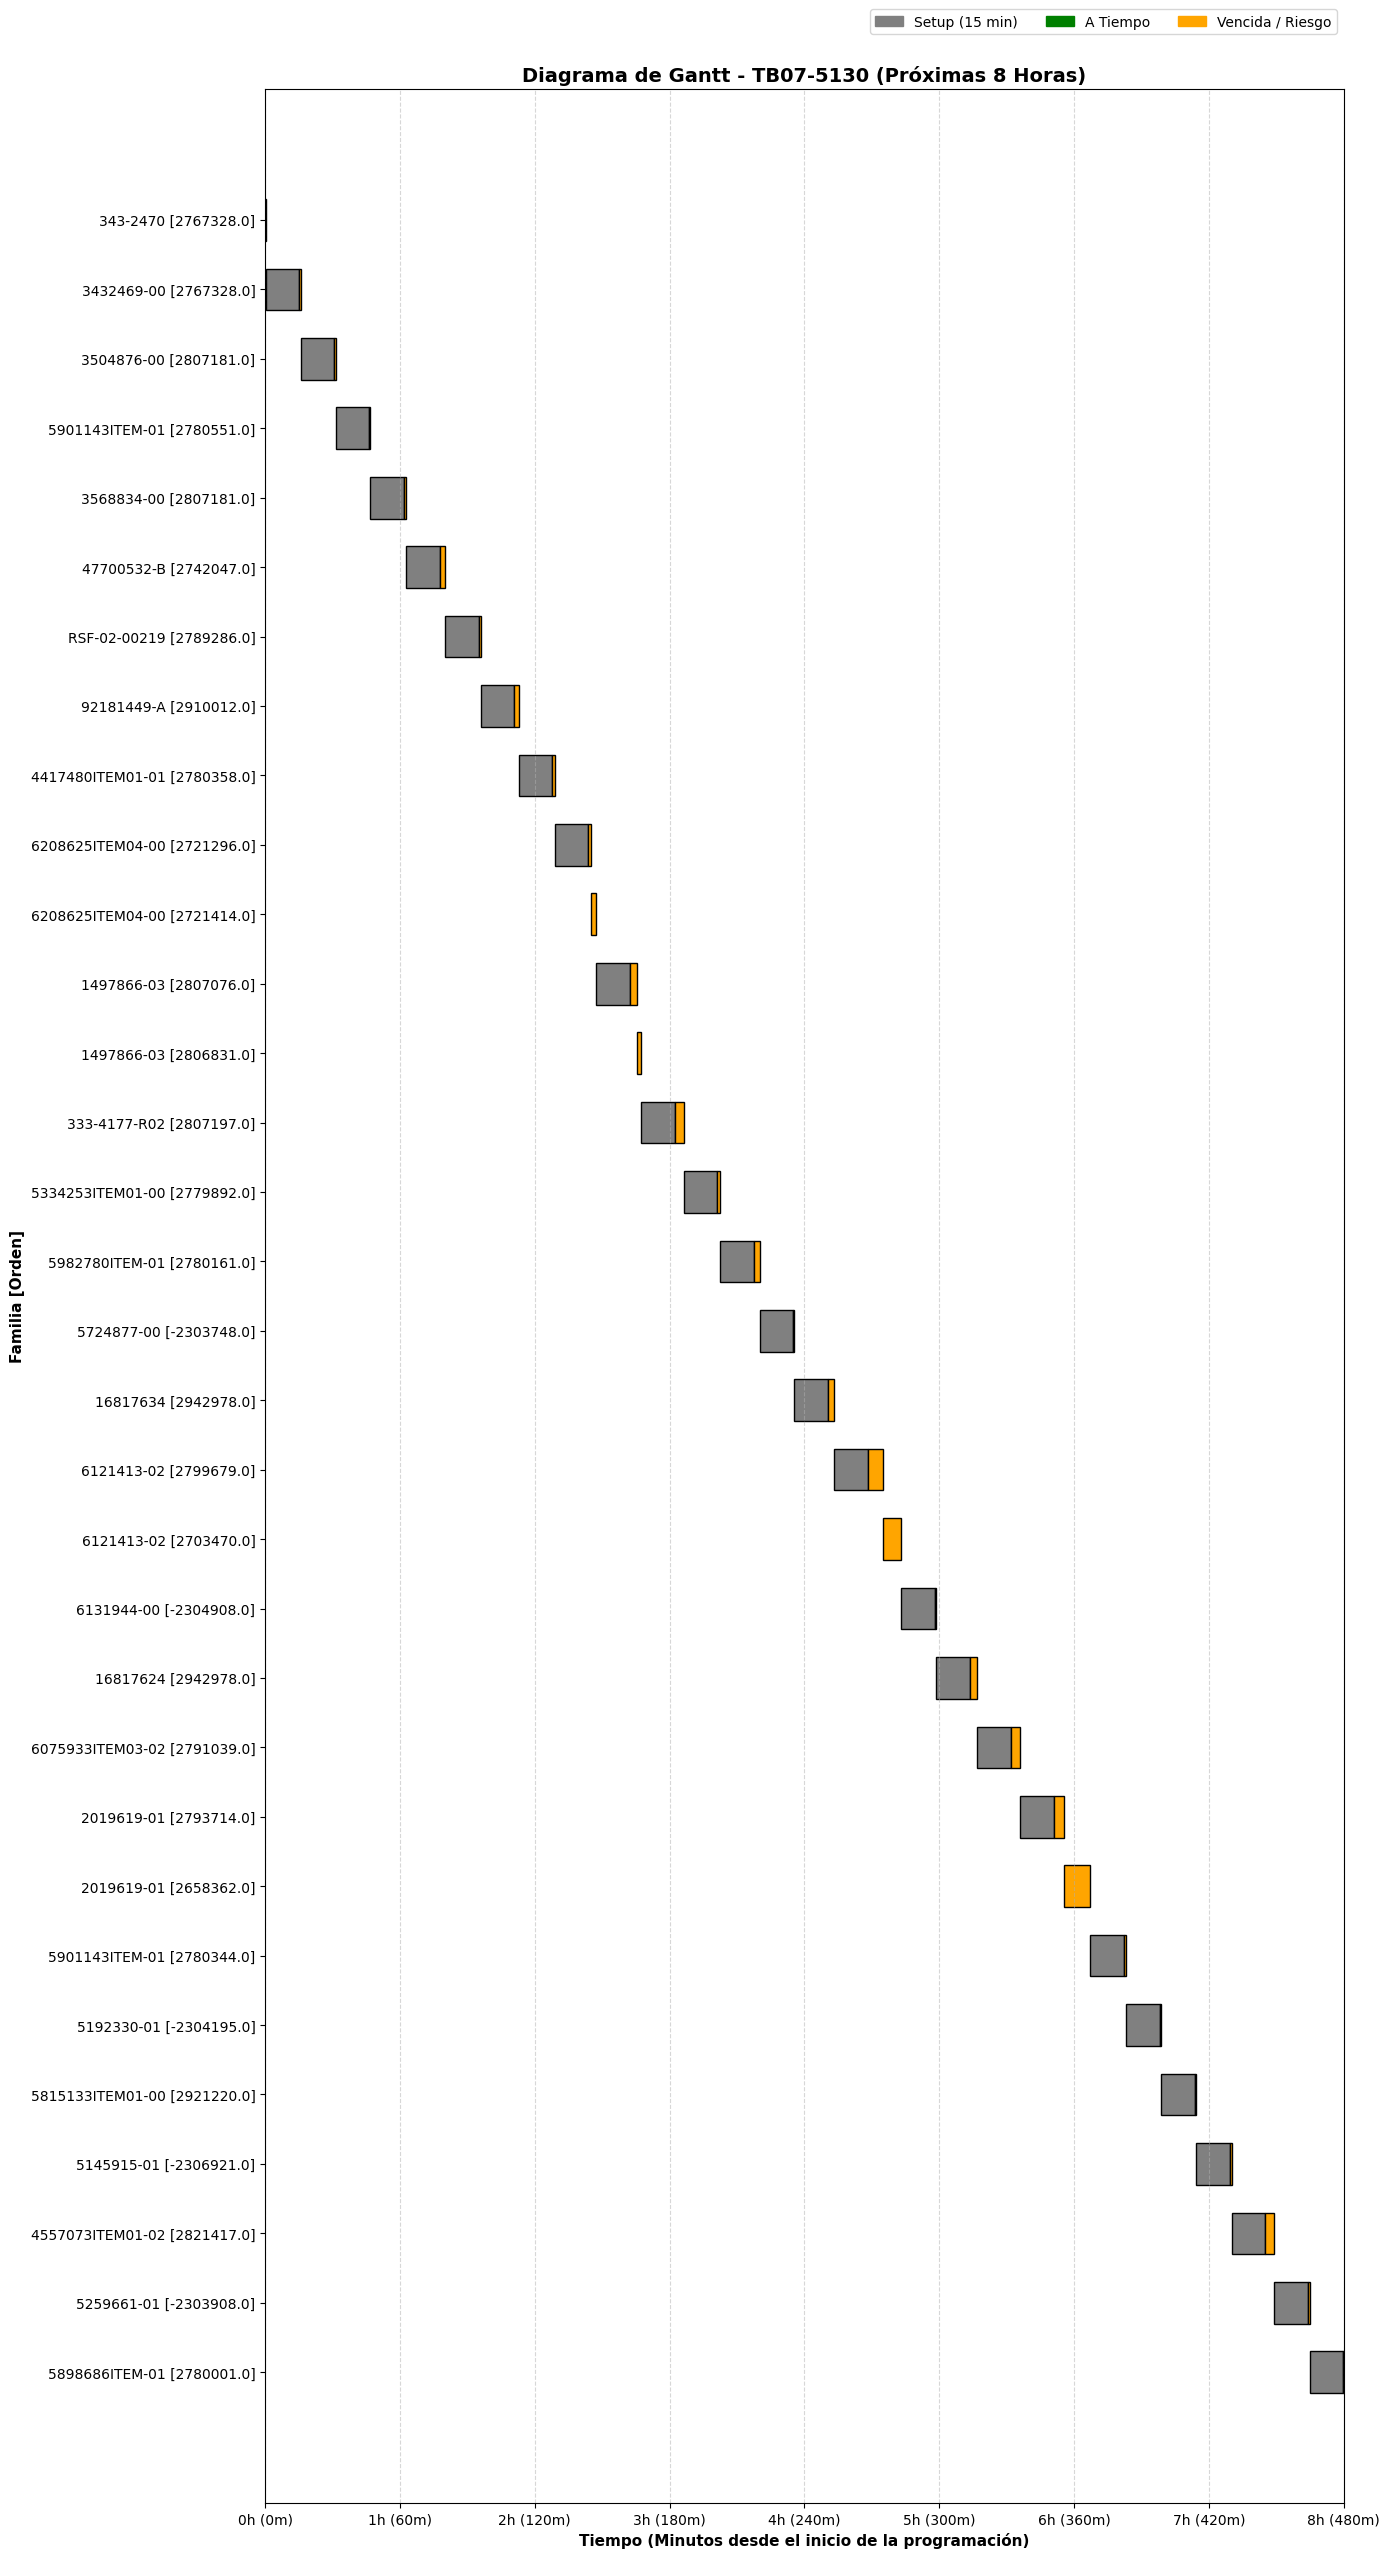

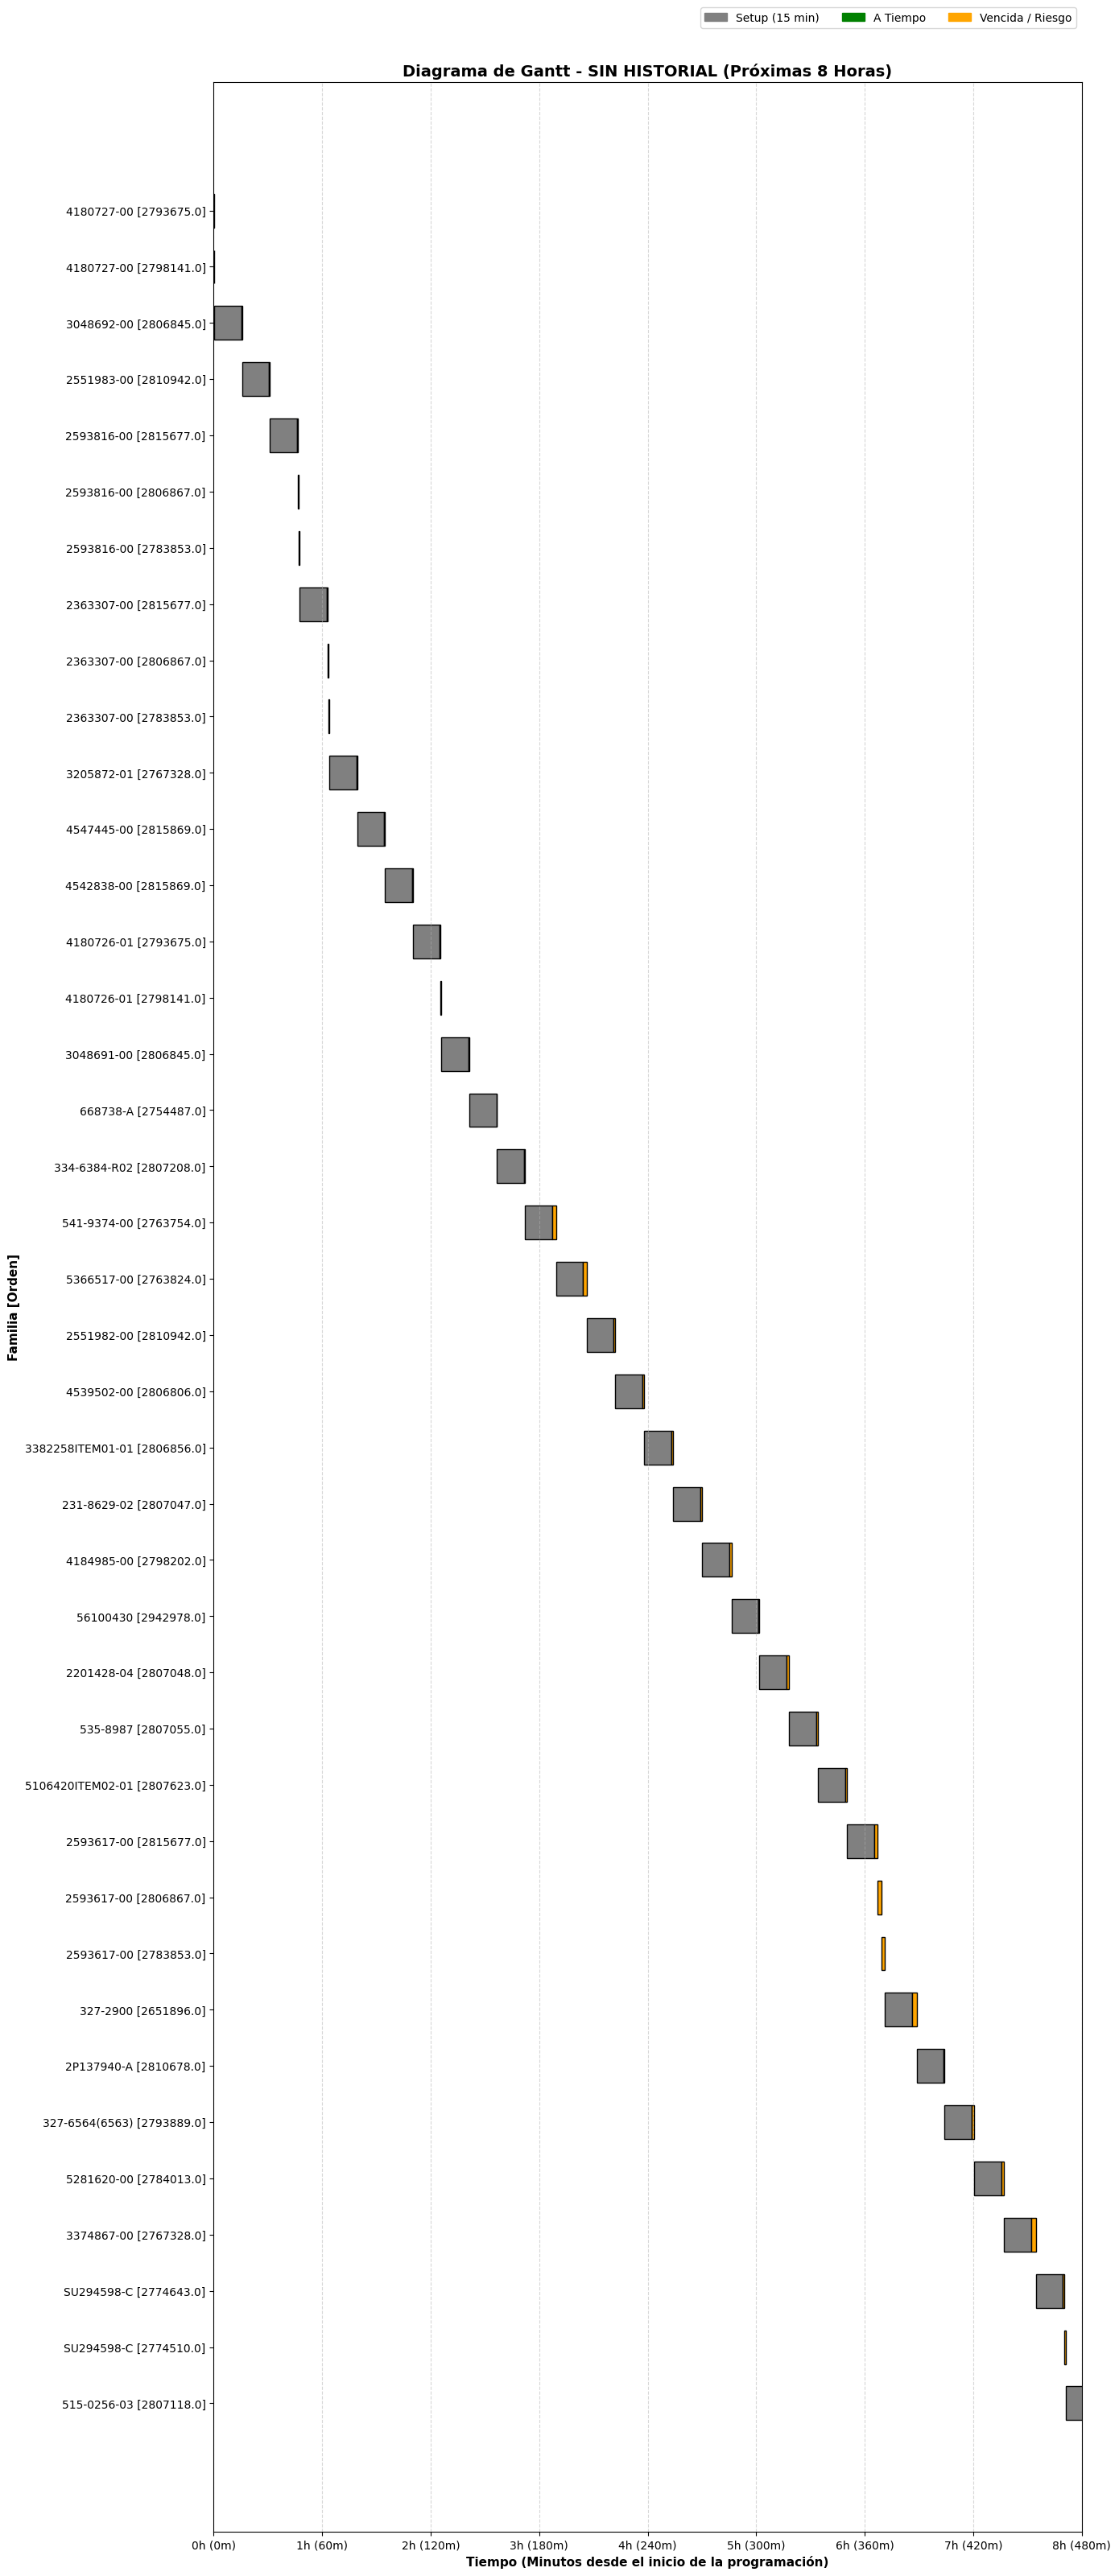

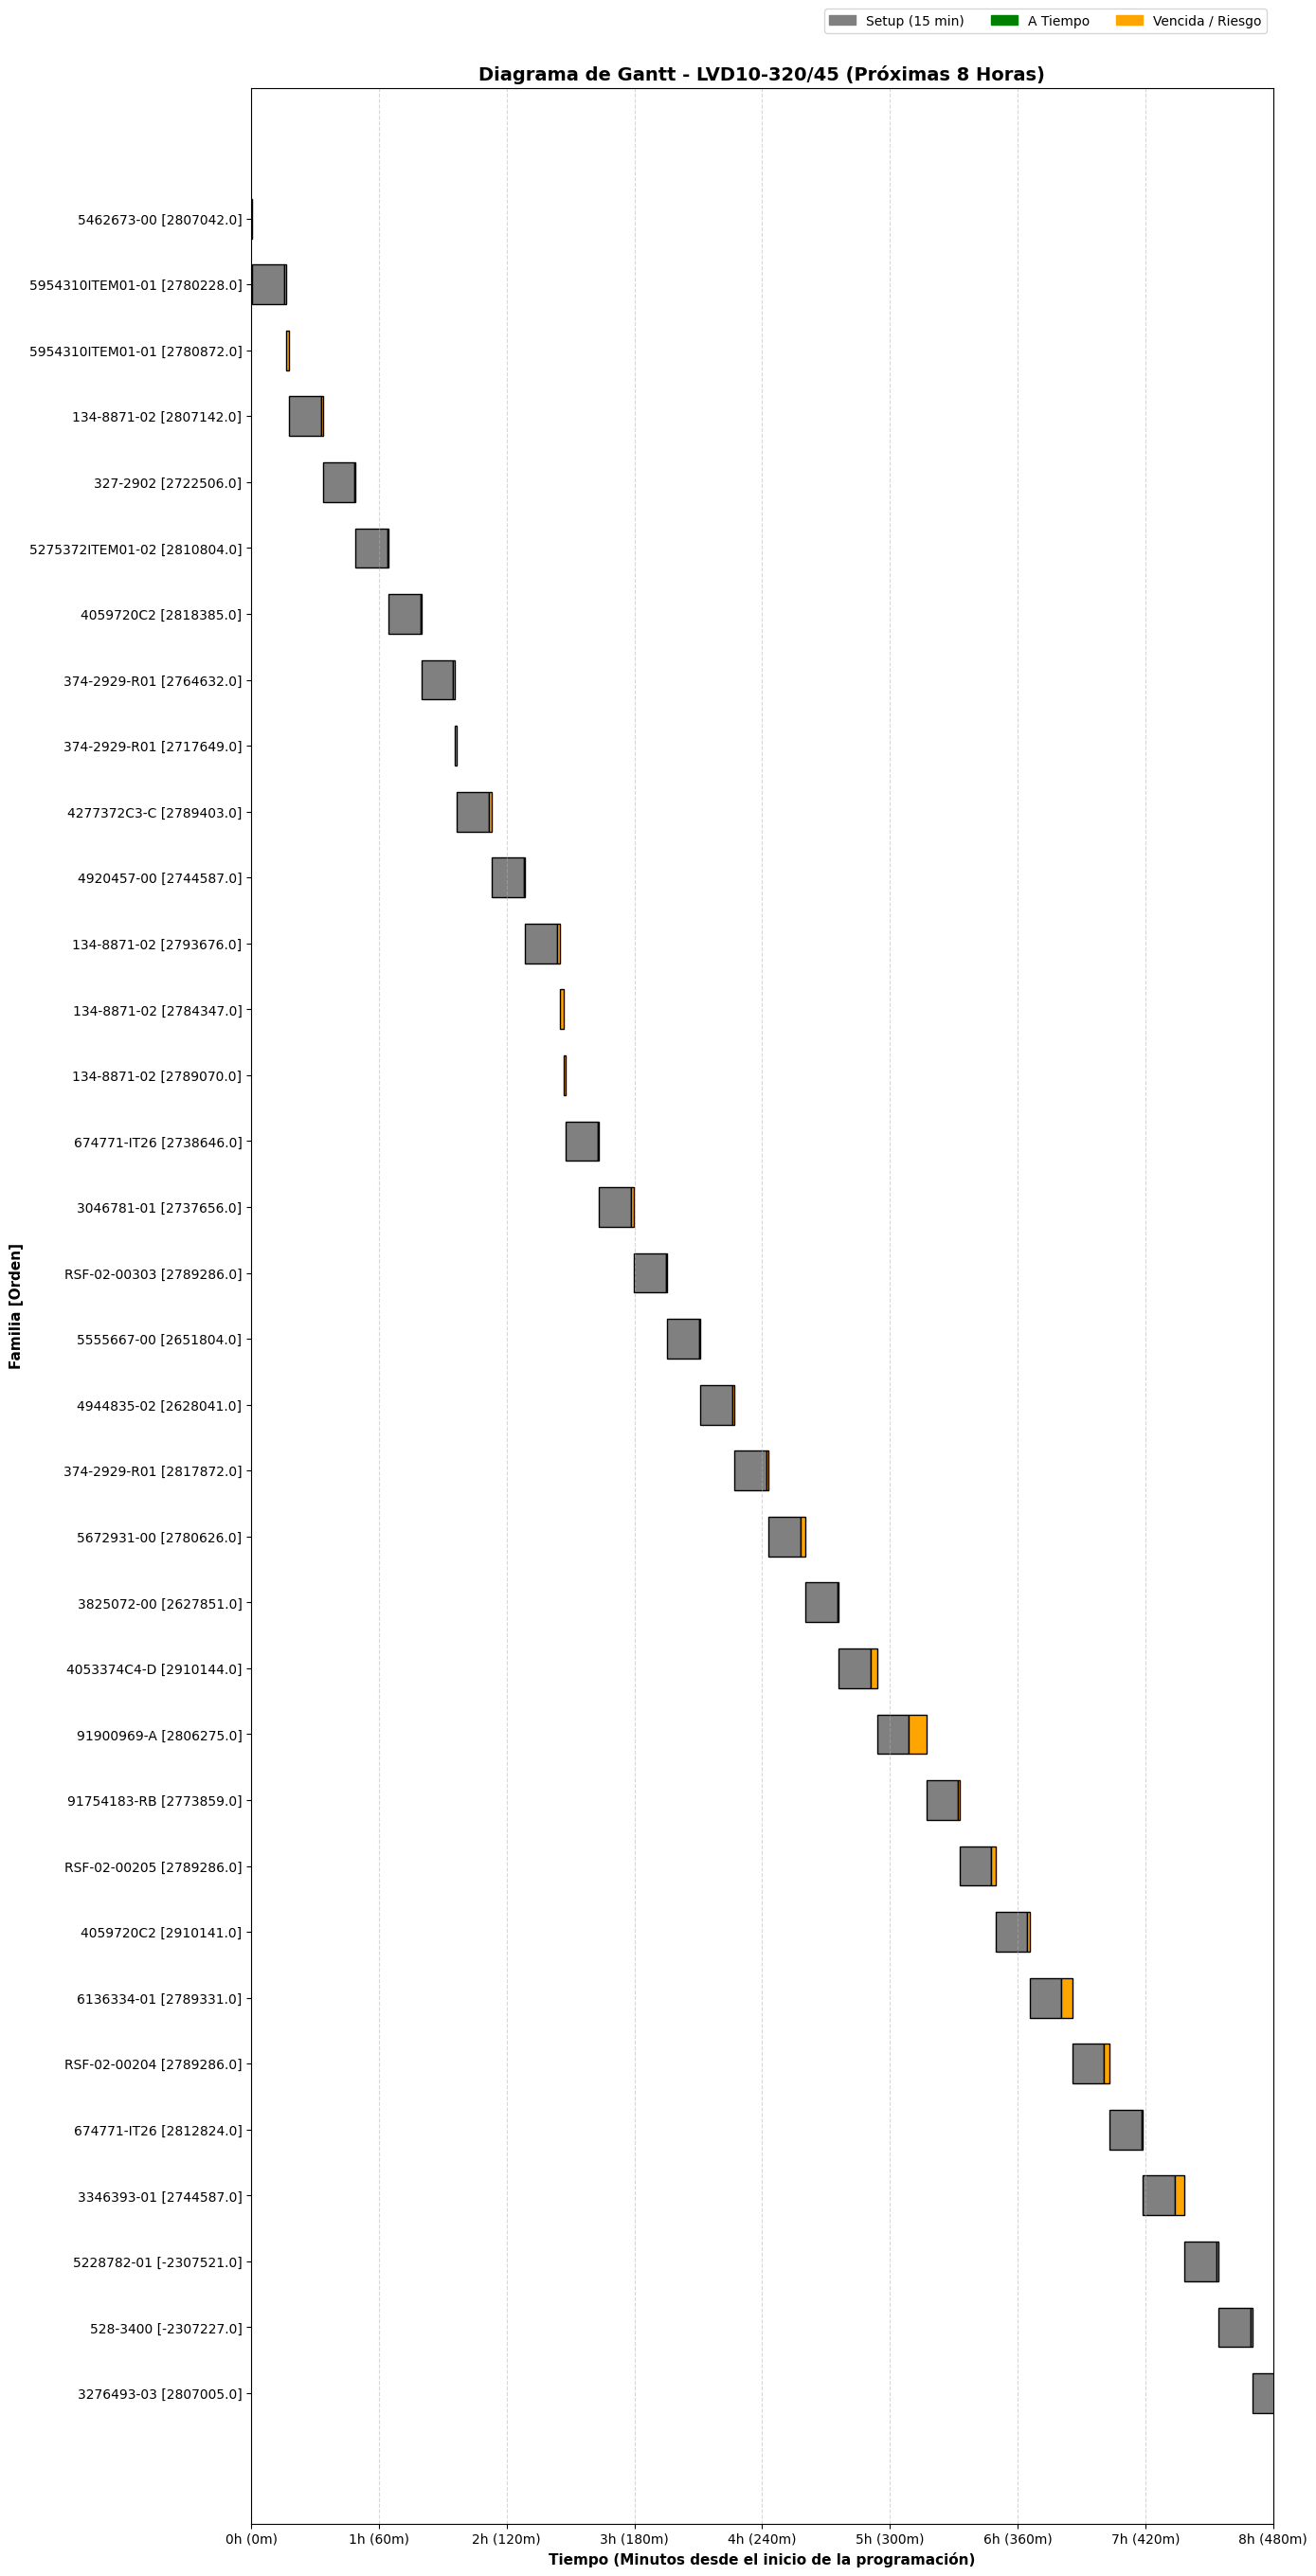

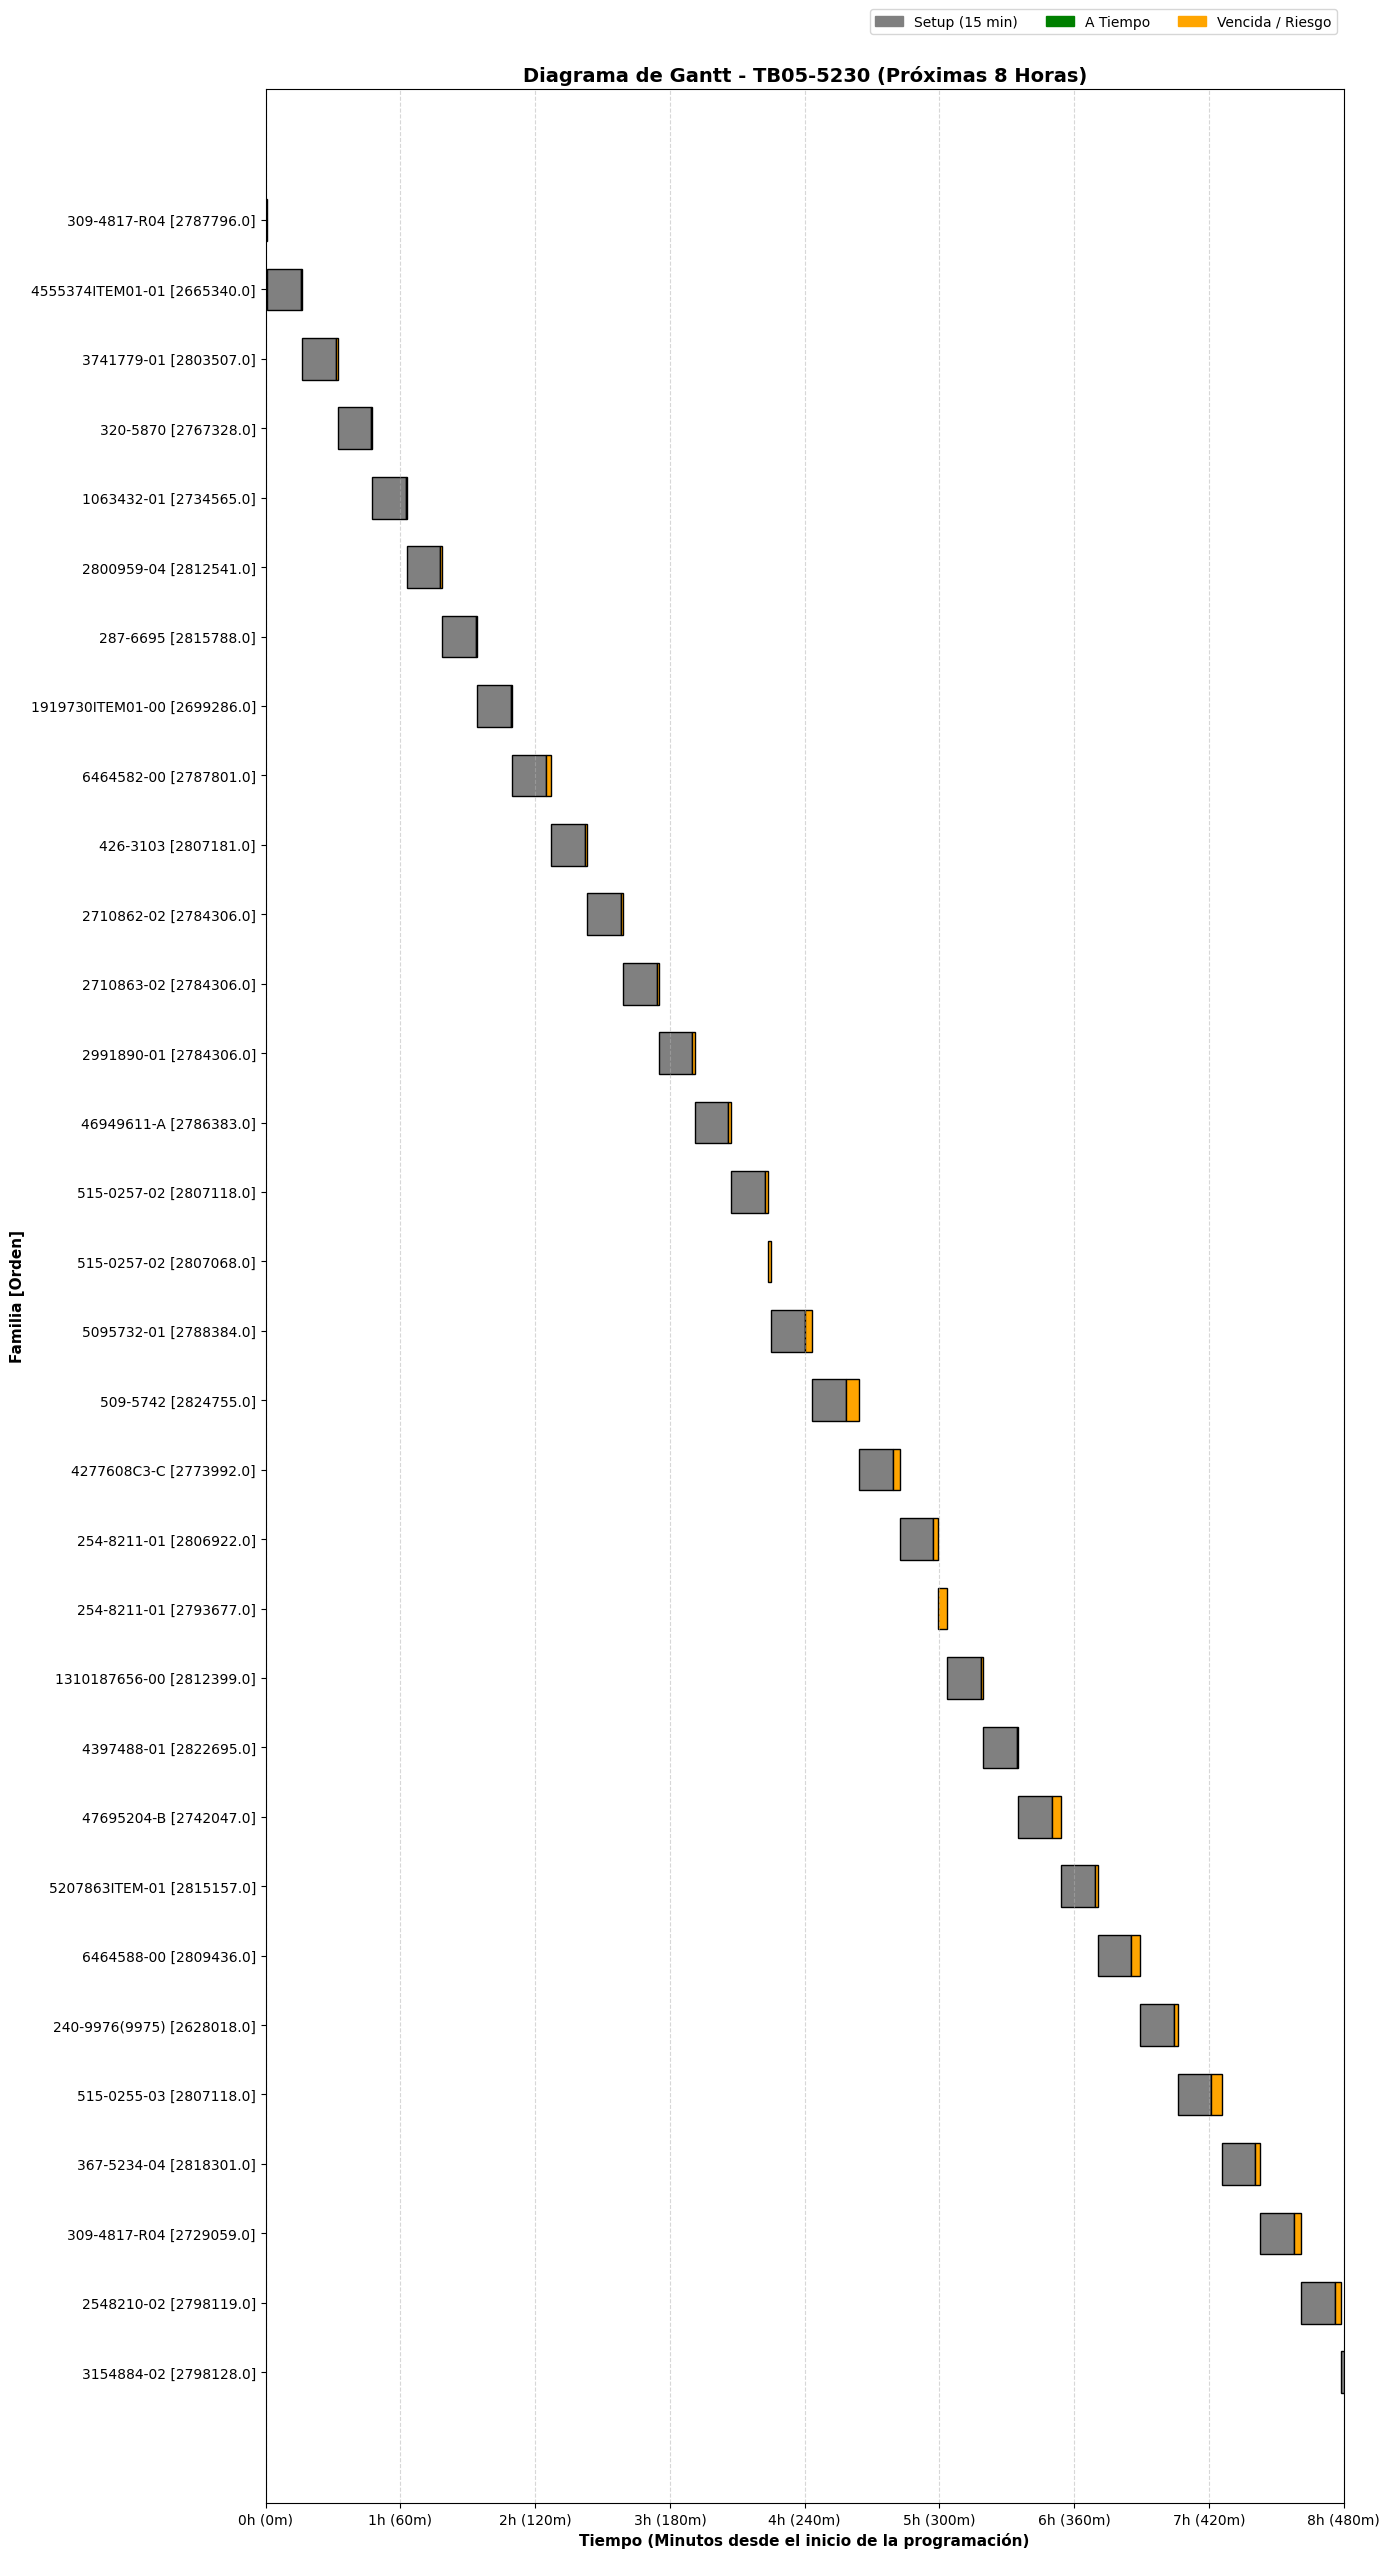

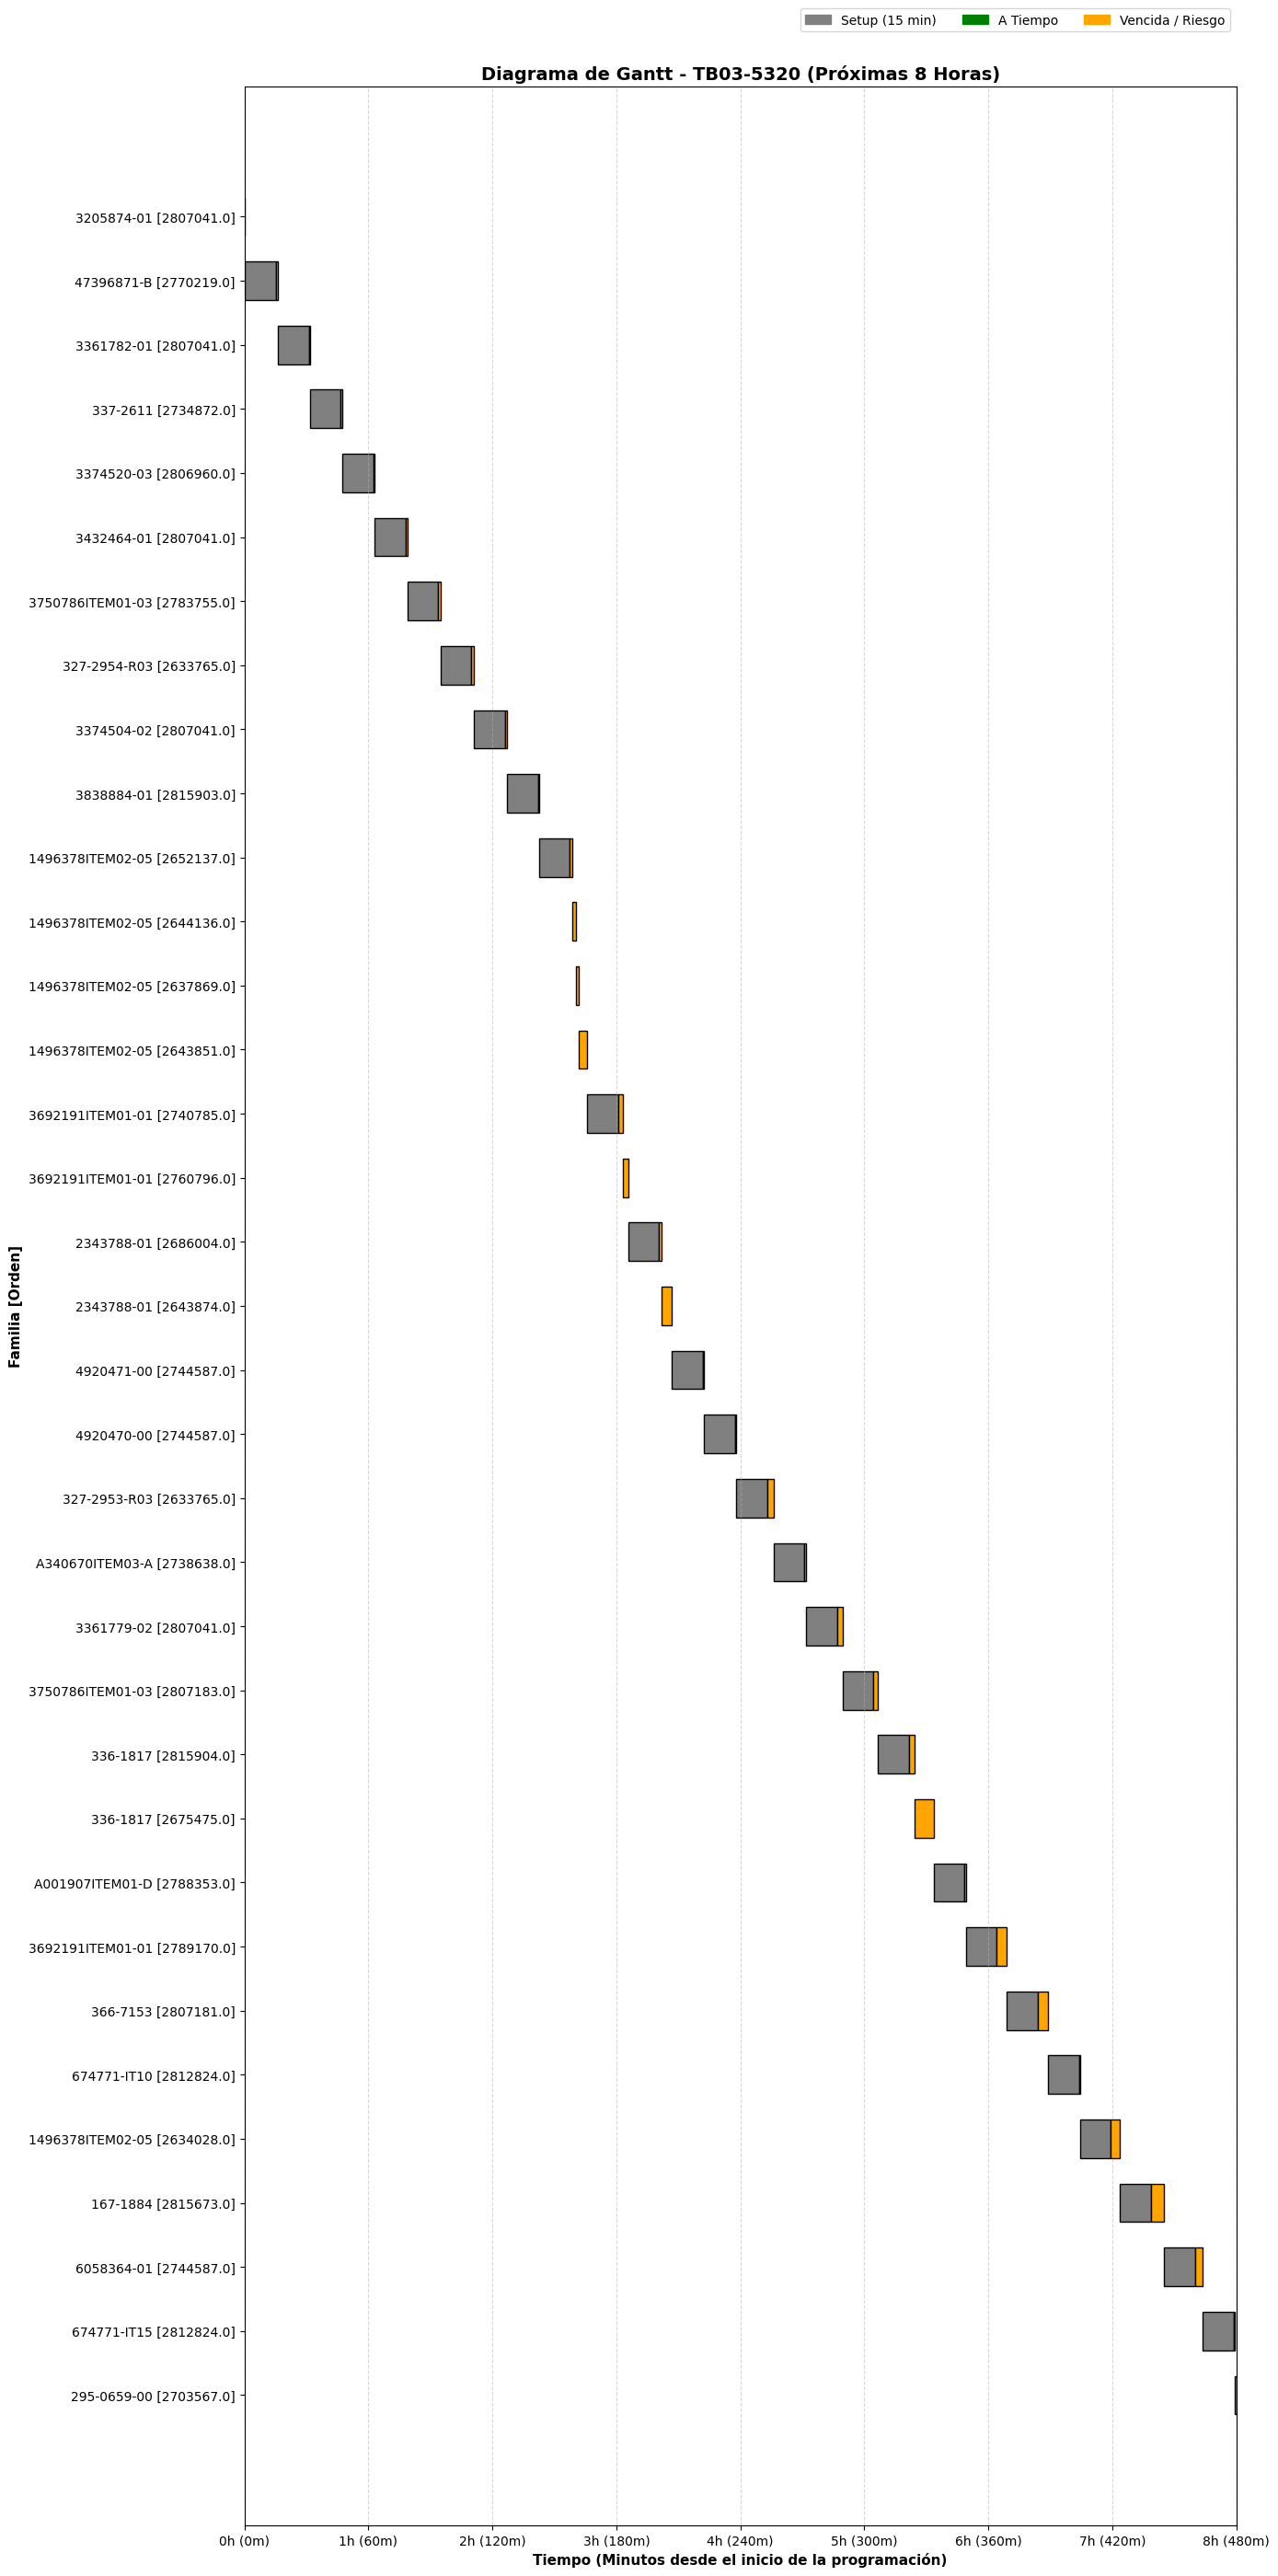

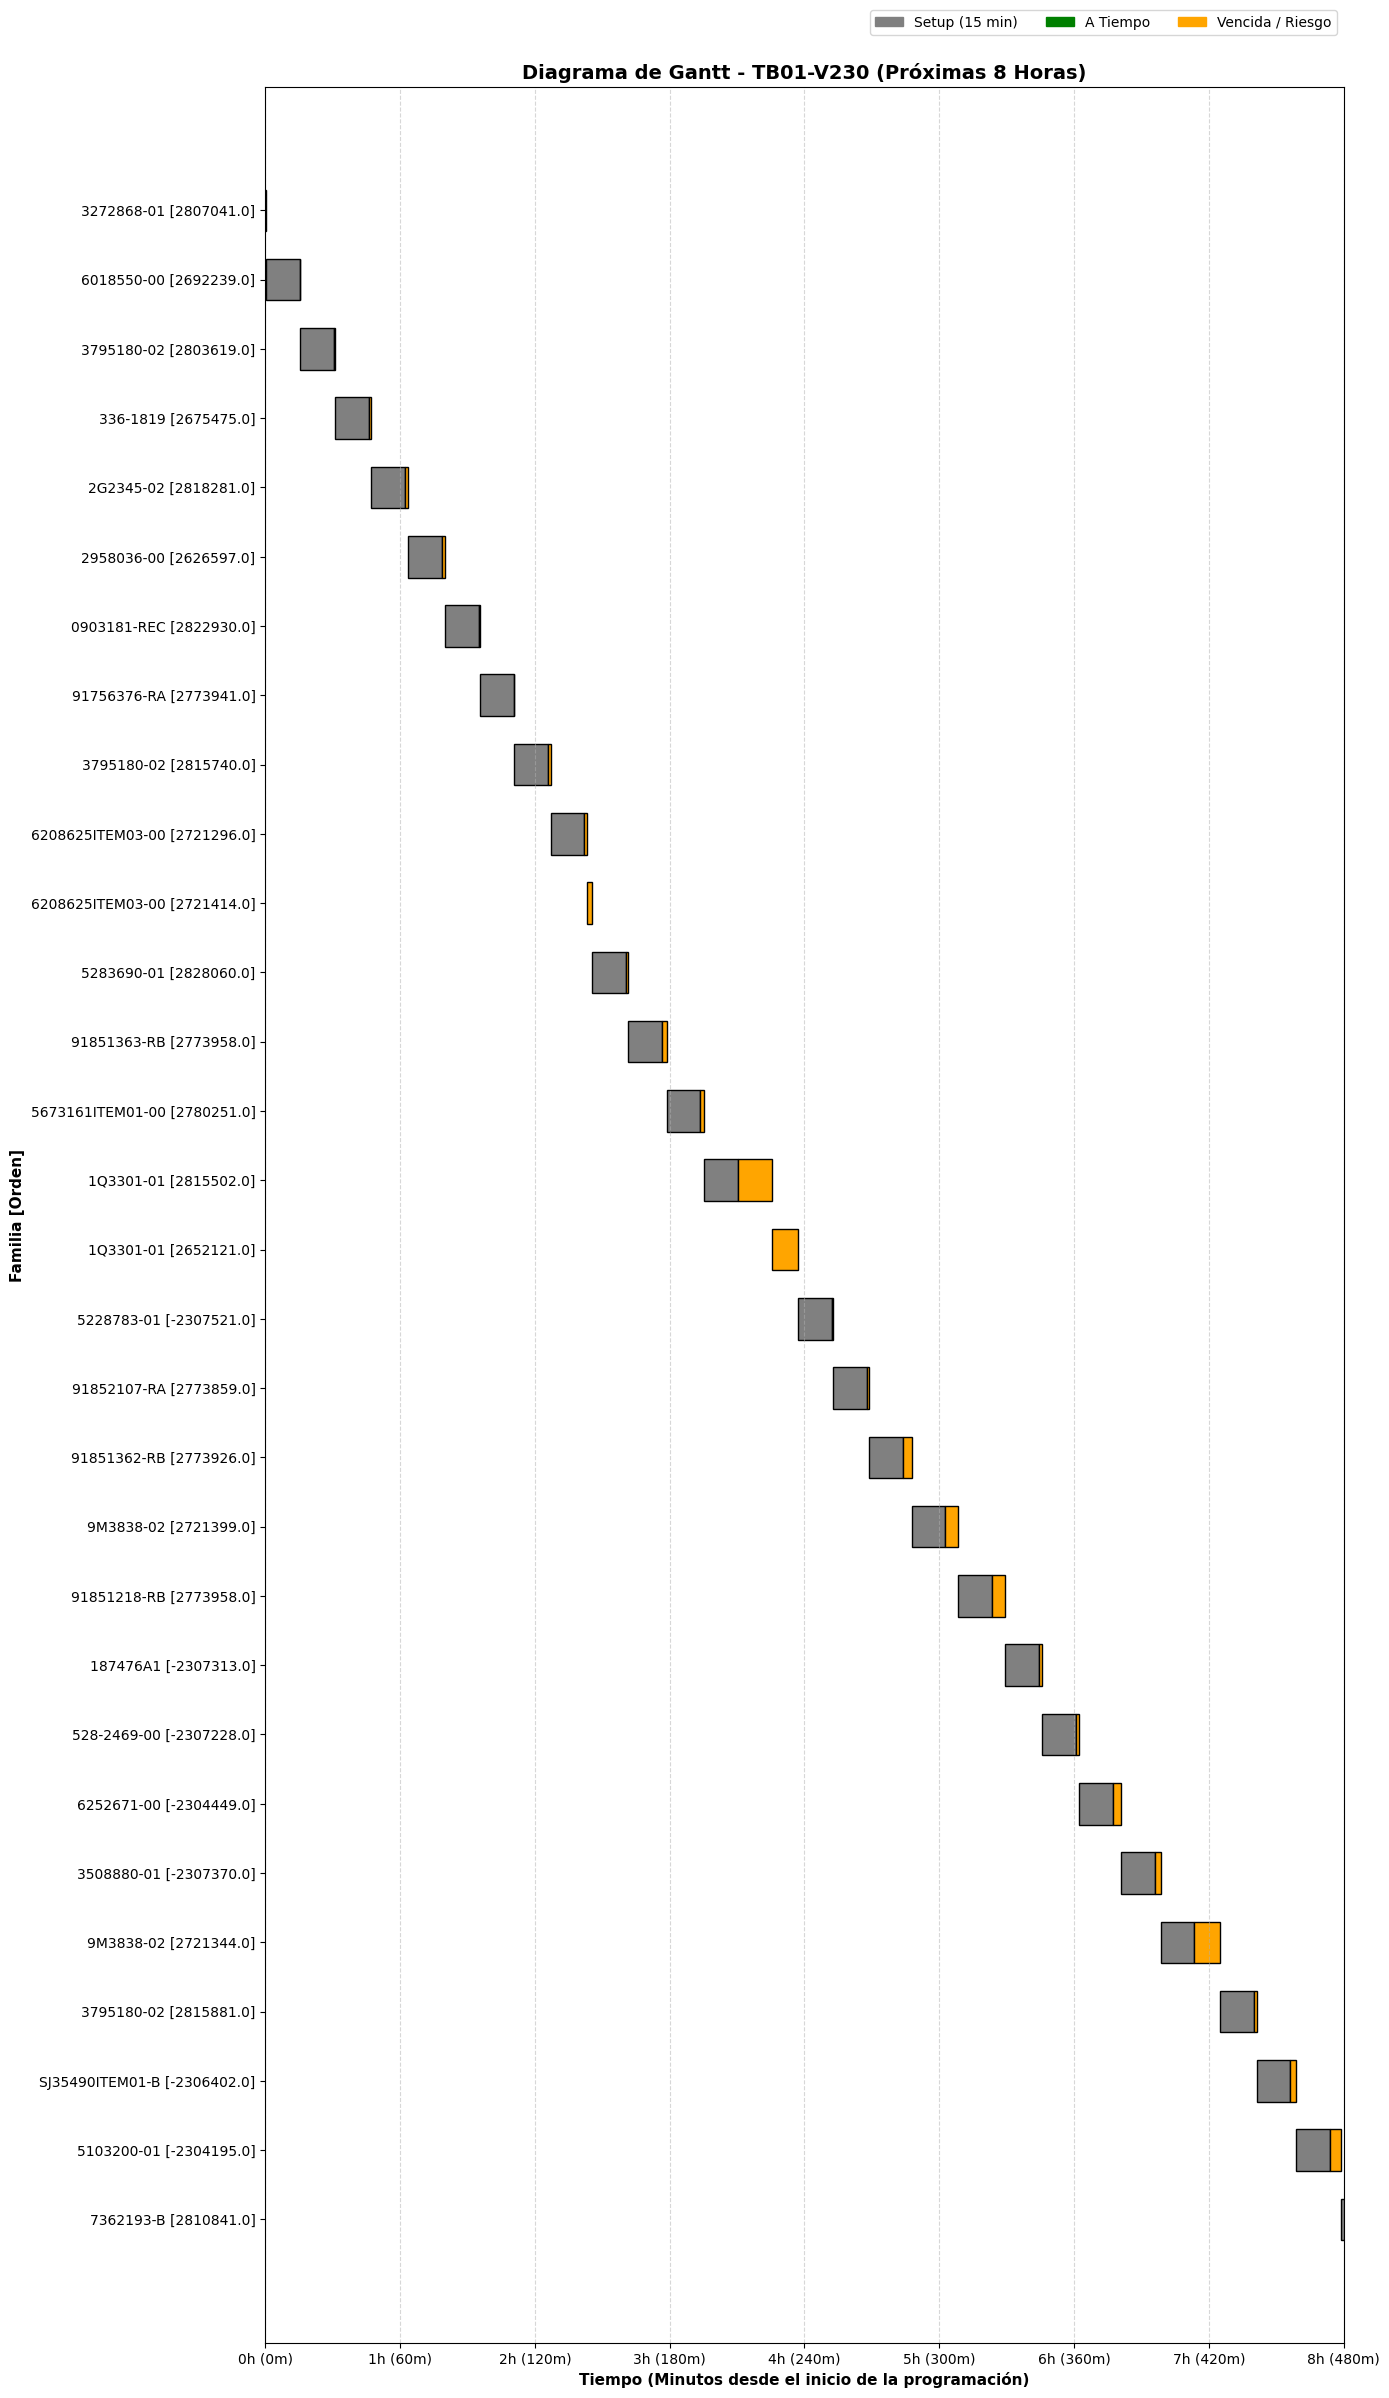

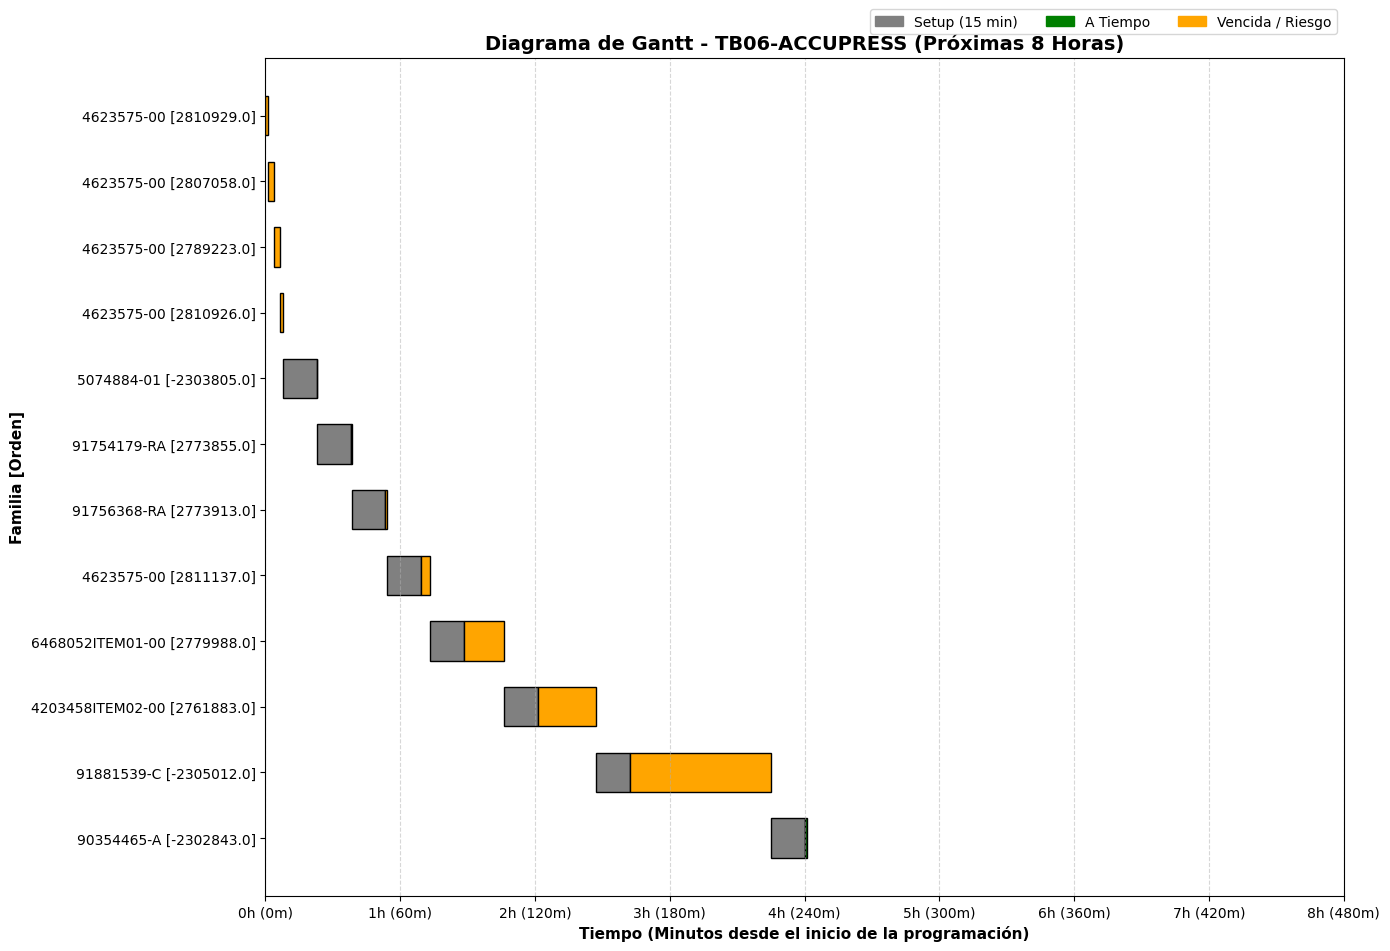

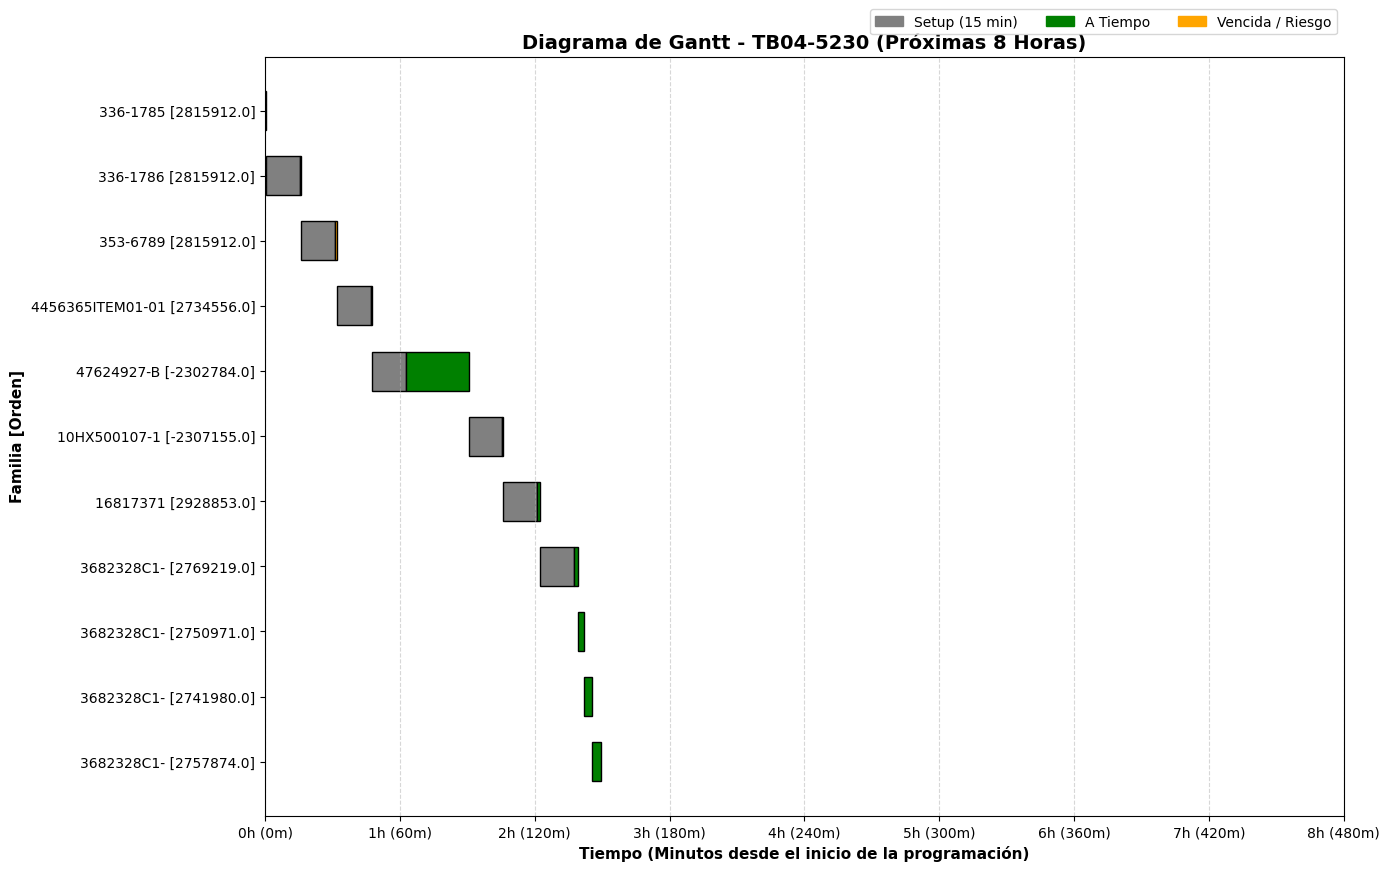

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== CALCULANDO CARGA DE TRABAJO POR MÁQUINA ===

=== GENERANDO GRÁFICO DE CARGA POR MÁQUINA ===


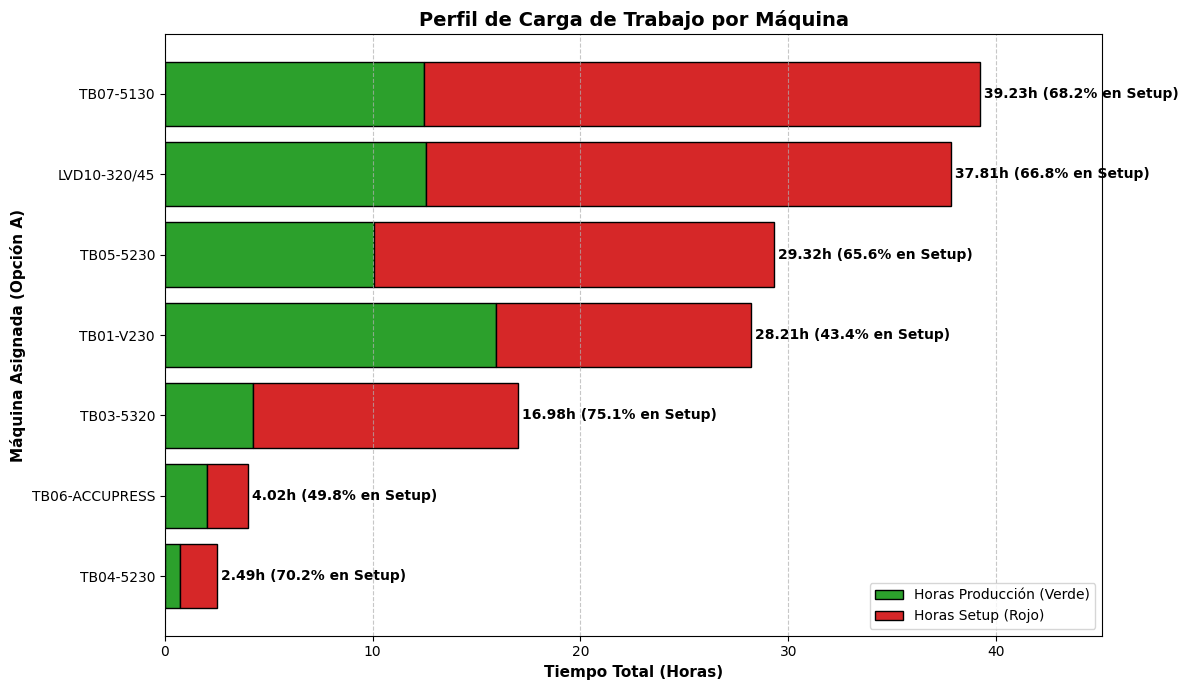

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Resumen de carga de trabajo generado y descargado: Resumen_Carga_Por_Maquina.xlsx

=== ÉXITO ===


In [ ]:
import pandas as pd
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def analizar_frecuencias_maquinas(df_hist, maquinas_caidas=[]):
    print("\n=== ANALIZANDO HISTORIAL DE MÁQUINAS ===")

    df_hist.columns = df_hist.columns.str.strip()

    if 'Numero de Parte' not in df_hist.columns or 'Maquina' not in df_hist.columns:
        raise ValueError("El archivo histórico debe contener las columnas 'Numero de Parte' y 'Maquina'.")

    # Limpiamos los nombres de las máquinas para asegurar que el cruce sea exacto
    df_hist['Maquina'] = df_hist['Maquina'].astype(str).str.strip()

    # =========================================================================
    # NUEVO: FILTRO DE MÁQUINAS CAÍDAS (RE-RUTEO DINÁMICO)
    # =========================================================================
    if maquinas_caidas:
        print(f"[ALERTA OPERATIVA] Descartando máquinas caídas: {maquinas_caidas}")
        print("El sistema re-ruteará el trabajo a las máquinas de respaldo (Opción B)...")
        # Filtramos eliminando cualquier fila donde la máquina esté en la lista de caídas
        df_hist = df_hist[~df_hist['Maquina'].isin(maquinas_caidas)]

        if df_hist.empty:
            print("[ADVERTENCIA] El historial se quedó vacío al quitar las máquinas caídas.")
            return pd.DataFrame()
    # =========================================================================

    frecuencias = df_hist.groupby(['Numero de Parte', 'Maquina']).size().reset_index(name='Veces_Usada')
    totales = frecuencias.groupby('Numero de Parte')['Veces_Usada'].transform('sum')
    frecuencias['Porcentaje'] = (frecuencias['Veces_Usada'] / totales) * 100
    frecuencias = frecuencias.sort_values(['Numero de Parte', 'Veces_Usada'], ascending=[True, False])

    resultados_maquinas = []
    evidencia_reporte = []

    for parte, grupo in frecuencias.groupby('Numero de Parte'):
        grupo = grupo.reset_index(drop=True)

        maq_a = grupo.loc[0, 'Maquina']
        pct_a = grupo.loc[0, 'Porcentaje']
        veces_a = grupo.loc[0, 'Veces_Usada']

        if len(grupo) > 1:
            maq_b = grupo.loc[1, 'Maquina']
            pct_b = grupo.loc[1, 'Porcentaje']
            veces_b = grupo.loc[1, 'Veces_Usada']
        else:
            maq_b = "N/A"
            pct_b = 0.0
            veces_b = 0

        resultados_maquinas.append({
            'Componente': parte,
            'Maquina_Opcion_A': maq_a,
            'Maquina_Opcion_B': maq_b
        })

        evidencia_reporte.append({
            'Numero de Parte': parte,
            'Maquina Opcion A': f"{maq_a} ({pct_a:.1f}% - {veces_a} veces)",
            'Maquina Opcion B': f"{maq_b} ({pct_b:.1f}% - {veces_b} veces)" if maq_b != "N/A" else "Sin registro alterno",
            'Total Corridas Historicas': totales.iloc[grupo.index[0]]
        })

    df_maquinas_maestro = pd.DataFrame(resultados_maquinas)
    df_reporte = pd.DataFrame(evidencia_reporte)

    output_reporte = "Reporte_Evidencia_Maquinas.xlsx"
    df_reporte.to_excel(output_reporte, index=False)
    files.download(output_reporte)

    return df_maquinas_maestro

def cargar_y_limpiar_datos():
    print("=== PASO 1: CARGA DE DATOS ===")
    print("Por favor sube el extracto de órdenes del ERP (Excel)...")
    uploaded_erp = files.upload()
    file_erp = list(uploaded_erp.keys())[0]
    df_erp = pd.read_excel(file_erp)

    df_erp = df_erp.drop(0)

    df_erp.columns = ["OrdenEPS","Año","Sem","Bloque","Critico","Cliente","Ciudad",
                      "Producto Terminado","Fecha","Real","Componente","Ing","Tipo",
                      "Transf","Proceso","Pzas","Hrs","/Celda","Cls","Color de pintura","Peso",
                      "Familia","Rec","Disp","Color","Anterior","Comentario","Doblez", "Biselado",
                      "Pulidor","Doblez-Rolado"]

    print("\nPor favor sube el catálogo 'Prioridades_Clientes.xlsx'...")
    uploaded_clientes = files.upload()
    file_clientes = list(uploaded_clientes.keys())[0]
    df_clientes = pd.read_excel(file_clientes)

    print("\nPor favor sube el historial de máquinas (Excel con 'Numero de Parte' y 'Maquina')...")
    uploaded_hist = files.upload()
    file_hist = list(uploaded_hist.keys())[0]
    df_hist = pd.read_excel(file_hist)

    # =========================================================================
    # INTERFAZ PARA CAPTURAR MÁQUINAS CAÍDAS
    # =========================================================================
    print("\n" + "="*60)
    print("¿Hay alguna máquina CAÍDA, SIN OPERADOR o en MANTENIMIENTO?")
    entrada_caidas = input("Escribe sus nombres separados por coma (ej. Dobladora 1, Prensa A) o presiona ENTER si todas operan normal: ")

    maquinas_caidas = []
    if entrada_caidas.strip():
        maquinas_caidas = [m.strip() for m in entrada_caidas.split(',')]
    print("="*60 + "\n")
    # =========================================================================

    # =========================================================================
    # CARGA DE CATÁLOGO DE PRODUCTOS VIP
    # =========================================================================
    print("\nPor favor sube el listado de Productos Estrella/VIP (Excel con columna 'Producto Terminado')...")
    uploaded_vip = files.upload()
    file_vip = list(uploaded_vip.keys())[0]
    df_vip = pd.read_excel(file_vip)

    if 'Producto Terminado' in df_vip.columns:
        productos_estrella = df_vip['Producto Terminado'].astype(str).str.strip().tolist()
    else:
        productos_estrella = df_vip.iloc[:, 0].astype(str).str.strip().tolist()
    print(f"[INFO] Se cargaron {len(productos_estrella)} productos con prioridad alta.")

    # --- 1. Análisis de Historial de Máquinas ---
    df_maquinas_rutas = analizar_frecuencias_maquinas(df_hist, maquinas_caidas)

    # --- 2. Limpieza, Vacunación y Rastreo de Rechazos ---
    lista_descartados = []

    mask_npi = df_erp["Ing"] == "NPI"
    rechazos_npi = df_erp[mask_npi].copy()
    if not rechazos_npi.empty:
        rechazos_npi["Motivo_Rechazo"] = "Excluido: Es proyecto NPI"
        lista_descartados.append(rechazos_npi)
    df_erp = df_erp[~mask_npi].copy()

    columnas_numericas = ["Hrs", "Pzas", "Rec", "Disp"]
    for col in columnas_numericas:
        if col in df_erp.columns:
            df_erp[col] = pd.to_numeric(df_erp[col], errors='coerce')

    mask_nulos = df_erp[['Fecha', 'Hrs', 'Pzas', 'Cliente']].isnull().any(axis=1)
    rechazos_nulos = df_erp[mask_nulos].copy()
    if not rechazos_nulos.empty:
        rechazos_nulos["Motivo_Rechazo"] = "Excluido: Falta Fecha, Hrs, Pzas o Cliente en el ERP"
        lista_descartados.append(rechazos_nulos)
    df_erp = df_erp[~mask_nulos].copy()

    mask_ceros = (df_erp["Pzas"] <= 0) | (df_erp["Hrs"] <= 0)
    rechazos_ceros = df_erp[mask_ceros].copy()
    if not rechazos_ceros.empty:
        rechazos_ceros["Motivo_Rechazo"] = "Excluido: Pzas o Hrs configuradas en 0"
        lista_descartados.append(rechazos_ceros)
    df_erp = df_erp[~mask_ceros].copy()

    df_erp["Rec"] = df_erp["Rec"].fillna(0)
    df_erp["Disp"] = df_erp["Disp"].fillna(0)

    # Cobertura estricta calculada contra la cantidad de piezas planificadas ("Pzas")
    df_erp["pzas_disponibles"] = df_erp["Rec"] + df_erp["Disp"]
    df_erp["pct_completo"] = df_erp["pzas_disponibles"] / df_erp["Pzas"]

    mask_material = ~(df_erp["pct_completo"] >= 0.5)

    rechazos_material = df_erp[mask_material].copy()
    if not rechazos_material.empty:
        rechazos_material["Motivo_Rechazo"] = "Bloqueo Operativo: Material disponible menor al 50% o datos nulos"
        lista_descartados.append(rechazos_material)

    df_erp = df_erp[~mask_material].copy()

    # --- 3. Consolidar y Exportar Archivo de Rechazos (CON ALERTA VIP) ---
    if lista_descartados:
        df_descartados = pd.concat(lista_descartados, ignore_index=True)

        # Limpiamos espacios para el match
        df_descartados['Producto Terminado'] = df_descartados['Producto Terminado'].astype(str).str.strip()

        # Agregamos la columna de alerta usando NumPy
        df_descartados['ALERTA_VIP'] = np.where(
            df_descartados['Producto Terminado'].isin(productos_estrella),
            '⚠️ SÍ - CRÍTICO',
            'Normal'
        )

        # Reordenamos las columnas para que lo importante quede a la izquierda
        cols_primarias = ['ALERTA_VIP', 'Motivo_Rechazo', 'Producto Terminado', 'OrdenEPS', 'Cliente', 'Pzas', 'pzas_disponibles']
        cols_restantes = [col for col in df_descartados.columns if col not in cols_primarias]
        df_descartados = df_descartados[cols_primarias + cols_restantes]

        output_rechazos = "Ordenes_Bloqueadas_Auditoria.xlsx"
        df_descartados.to_excel(output_rechazos, index=False)
        files.download(output_rechazos)
        print(f"\n[INFO] Se exportó el archivo de auditoría con {len(df_descartados)} órdenes bloqueadas: {output_rechazos}")

    # --- 4. Tiempos y Llaves Maestras ---
    df_erp["tiempo_ciclo_min"] = (df_erp["Hrs"] / df_erp["Pzas"]) * df_erp["pzas_disponibles"] * 60
    ahora = pd.Timestamp.now()
    df_erp["Real"] = pd.to_datetime(df_erp["Real"])
    df_erp["due_date_min"] = (df_erp["Real"] - ahora).dt.total_seconds() / 60

    df_erp["familia"] = df_erp["Componente"]
    df_erp["orden"] = df_erp["OrdenEPS"].astype(str) + "_" + df_erp["Componente"].astype(str)

    df_erp['Cliente_Key'] = df_erp['Cliente'].astype(str).str.strip().str.upper()
    df_clientes['Cliente_Key'] = df_clientes['Nombre_Cliente'].astype(str).str.strip().str.upper()

    df_modelo = pd.merge(df_erp, df_clientes[['Cliente_Key', 'Prioridad_Gerencia']], on='Cliente_Key', how='left')
    df_modelo['prioridad'] = df_modelo['Prioridad_Gerencia'].fillna(4.0)

    # --- APLICACIÓN DEL BOOST DE PRIORIDAD PARA ÓRDENES QUE SÍ PASARON ---
    FACTOR_BOOST = 2.5

    df_modelo['Producto Terminado'] = df_modelo['Producto Terminado'].astype(str).str.strip()
    mask_pt_prio = df_modelo['Producto Terminado'].isin(productos_estrella)

    # =========================================================================
    # NUEVA COLUMNA: Etiqueta visible para el Excel Final
    # =========================================================================
    df_modelo['Es_VIP'] = np.where(mask_pt_prio, '⭐ SÍ', 'No')
    # =========================================================================

    # Aplicamos el multiplicador matemático
    df_modelo.loc[mask_pt_prio, 'prioridad'] = df_modelo.loc[mask_pt_prio, 'prioridad'] * FACTOR_BOOST

    df_modelo = pd.merge(df_modelo, df_maquinas_rutas, on='Componente', how='left')
    df_modelo['Maquina_Opcion_A'] = df_modelo['Maquina_Opcion_A'].fillna("SIN HISTORIAL")
    df_modelo['Maquina_Opcion_B'] = df_modelo['Maquina_Opcion_B'].fillna("SIN HISTORIAL")

    print(f"\nDatos listos: {len(df_modelo)} órdenes viables para programar.")
    return df_modelo

def optimizador_atcs_paralelo(df):
    print("\n=== PASO 2: OPTIMIZANDO SECUENCIA EN PARALELO (ATCS POR MÁQUINA) ===")
    secuencia_global = []
    SETUP_MIN = 15

    maquinas_disponibles = df['Maquina_Opcion_A'].unique()

    for maquina in maquinas_disponibles:
        df_maquina = df[df['Maquina_Opcion_A'] == maquina].copy()

        tiempo_actual = 0
        familia_actual = None
        p_promedio = df_maquina["tiempo_ciclo_min"].mean() if not df_maquina.empty else 1

        while len(df_maquina) > 0:
            if familia_actual is None:
                df_maquina["setup"] = 0
            else:
                df_maquina["setup"] = np.where(df_maquina["familia"] == familia_actual, 0, SETUP_MIN)

            df_maquina["slack_real"] = df_maquina["due_date_min"] - (df_maquina["tiempo_ciclo_min"] + df_maquina["setup"]) - tiempo_actual

            df_maquina["slack_real"] = df_maquina["slack_real"].astype(float)
            df_maquina["setup"] = df_maquina["setup"].astype(float)
            df_maquina["tiempo_ciclo_min"] = df_maquina["tiempo_ciclo_min"].astype(float)
            df_maquina["prioridad"] = df_maquina["prioridad"].astype(float)

            urgencia_normal = np.exp(-(df_maquina["slack_real"].clip(lower=0)) / float(p_promedio))
            horas_tarde = (np.abs(df_maquina["slack_real"].clip(upper=0)) / 60.0)
            multiplicador_tardanza = 1.0 + (0.1 * horas_tarde)
            factor_setup = np.exp(-(df_maquina["setup"]) / float(SETUP_MIN))

            df_maquina["score_atcs"] = (df_maquina["prioridad"] / df_maquina["tiempo_ciclo_min"]) * urgencia_normal * factor_setup * multiplicador_tardanza

            siguiente = df_maquina.sort_values(by="score_atcs", ascending=False).iloc[0]

            inicio = tiempo_actual + siguiente["setup"]
            fin = inicio + siguiente["tiempo_ciclo_min"]

            secuencia_global.append({
                **siguiente.to_dict(),
                "inicio_min": inicio,
                "fin_min": fin,
                "setup_aplicado": siguiente["setup"]
            })

            tiempo_actual = fin
            familia_actual = siguiente["familia"]
            df_maquina = df_maquina.drop(siguiente.name)

    return pd.DataFrame(secuencia_global)

def generar_gantt_por_maquina(resultado):
    print("\n=== PASO 3: GENERANDO GANTT POR MÁQUINA (PRÓXIMAS 8 HORAS) ===")
    LIMITE_MINUTOS = 8 * 60

    df_gantt_global = resultado[resultado['inicio_min'] - resultado['setup_aplicado'] < LIMITE_MINUTOS].copy()

    if df_gantt_global.empty:
        print("No hay órdenes programadas dentro de las próximas 8 horas para graficar.")
        return

    maquinas = df_gantt_global['Maquina_Opcion_A'].unique()

    for maquina in maquinas:
        df_maquina = df_gantt_global[df_gantt_global['Maquina_Opcion_A'] == maquina].copy()

        if df_maquina.empty:
            continue

        df_maquina = df_maquina.iloc[::-1]

        altura_grafico = max(4, len(df_maquina) * 0.8)
        fig, ax = plt.subplots(figsize=(14, altura_grafico))

        for _, row in df_maquina.iterrows():
            orden_etiqueta = f"{row['familia']} [{row['OrdenEPS']}]"
            inicio_operacion = row['inicio_min']
            duracion_operacion = row['tiempo_ciclo_min']
            setup = row['setup_aplicado']
            estado = row['Estado']

            if setup > 0:
                inicio_setup = inicio_operacion - setup
                ax.barh(orden_etiqueta, setup, left=inicio_setup, color='grey', edgecolor='black', height=0.6)

            color_op = 'green' if estado == "A TIEMPO" else 'orange'
            ax.barh(orden_etiqueta, duracion_operacion, left=inicio_operacion, color=color_op, edgecolor='black', height=0.6)

        ax.set_xlim(0, LIMITE_MINUTOS)
        ax.set_xlabel("Tiempo (Minutos desde el inicio de la programación)", fontsize=11, fontweight='bold')
        ax.set_ylabel("Familia [Orden]", fontsize=11, fontweight='bold')
        ax.set_title(f"Diagrama de Gantt - {maquina} (Próximas 8 Horas)", fontsize=14, fontweight='bold')

        ticks = np.arange(0, LIMITE_MINUTOS + 60, 60)
        ax.set_xticks(ticks)
        ax.set_xticklabels([f"{int(t/60)}h ({t}m)" for t in ticks])

        red_patch = mpatches.Patch(color='grey', label='Setup (15 min)')
        green_patch = mpatches.Patch(color='green', label='A Tiempo')
        orange_patch = mpatches.Patch(color='orange', label='Vencida / Riesgo')

        ax.legend(handles=[red_patch, green_patch, orange_patch], loc='lower right', bbox_to_anchor=(1, 1.02), ncol=3)

        plt.grid(axis='x', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

def calcular_carga_por_maquina(df_secuencia):
    print("\n=== CALCULANDO CARGA DE TRABAJO POR MÁQUINA ===")

    df_validas = df_secuencia[df_secuencia['Maquina_Opcion_A'] != "SIN HISTORIAL"].copy()

    if df_validas.empty:
        print("No hay datos suficientes de máquinas para calcular la carga.")
        return pd.DataFrame()

    resumen_carga = df_validas.groupby('Maquina_Opcion_A').agg(
        Total_Ordenes=('orden', 'count'),
        Minutos_Setup=('setup_aplicado', 'sum'),
        Minutos_Produccion=('tiempo_ciclo_min', 'sum')
    ).reset_index()

    resumen_carga['Minutos_Totales'] = resumen_carga['Minutos_Setup'] + resumen_carga['Minutos_Produccion']
    resumen_carga['Horas_Setup'] = (resumen_carga['Minutos_Setup'] / 60).round(2)
    resumen_carga['Horas_Produccion'] = (resumen_carga['Minutos_Produccion'] / 60).round(2)
    resumen_carga['Horas_Totales_Carga'] = (resumen_carga['Minutos_Totales'] / 60).round(2)
    resumen_carga['%_Tiempo_Setup'] = ((resumen_carga['Minutos_Setup'] / resumen_carga['Minutos_Totales']) * 100).round(1)

    resumen_carga = resumen_carga.sort_values(by='Horas_Totales_Carga', ascending=False)

    columnas_finales = [
        'Maquina_Opcion_A', 'Total_Ordenes',
        'Horas_Setup', 'Horas_Produccion', 'Horas_Totales_Carga', '%_Tiempo_Setup'
    ]

    return resumen_carga[columnas_finales]

def graficar_carga_por_maquina(df_carga):
    print("\n=== GENERANDO GRÁFICO DE CARGA POR MÁQUINA ===")

    if df_carga.empty:
        print("No hay datos para graficar la carga.")
        return

    df_plot = df_carga.sort_values(by='Horas_Totales_Carga', ascending=True)

    fig, ax = plt.subplots(figsize=(12, 7))

    maquinas = df_plot['Maquina_Opcion_A']
    produccion = df_plot['Horas_Produccion']
    setup = df_plot['Horas_Setup']

    ax.barh(maquinas, produccion, color='#2ca02c', edgecolor='black', label='Horas Producción (Verde)')
    ax.barh(maquinas, setup, left=produccion, color='#d62728', edgecolor='black', label='Horas Setup (Rojo)')

    ax.set_xlabel('Tiempo Total (Horas)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Máquina Asignada (Opción A)', fontsize=11, fontweight='bold')
    ax.set_title('Perfil de Carga de Trabajo por Máquina', fontsize=14, fontweight='bold')

    for index, value in enumerate(df_plot['Horas_Totales_Carga']):
        pct_setup = df_plot.iloc[index]['%_Tiempo_Setup']
        ax.text(value + 0.2, index, f"{value}h ({pct_setup}% en Setup)", va='center', fontsize=10, fontweight='bold')

    max_horas = df_plot['Horas_Totales_Carga'].max()
    ax.set_xlim(0, max_horas * 1.15)

    ax.legend(loc='lower right')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# ===============================
# EJECUCIÓN PRINCIPAL
# ===============================
try:
    datos_modelo = cargar_y_limpiar_datos()
    resultado = optimizador_atcs_paralelo(datos_modelo)

    resultado["Minutos_Restantes_Entrega"] = resultado["due_date_min"] - resultado["fin_min"]
    resultado["Estado"] = np.where(resultado["Minutos_Restantes_Entrega"] < 0, "VENCIDO / RIESGO", "A TIEMPO")

    generar_gantt_por_maquina(resultado)

    # =========================================================================
    # CONVERSIÓN DE MINUTOS A FECHA Y HORA REAL (AJUSTE DE ZONA HORARIA)
    # =========================================================================
    # 1. Tomamos el momento exacto ajustado a tu zona horaria local
    hora_arranque = pd.Timestamp.now(tz='America/Monterrey').tz_localize(None)

    # 2. Sumamos los minutos relativos a la hora de arranque usando Timedeltas
    resultado['Fecha_Hora_Inicio'] = hora_arranque + pd.to_timedelta(resultado['inicio_min'], unit='m')
    resultado['Fecha_Hora_Fin'] = hora_arranque + pd.to_timedelta(resultado['fin_min'], unit='m')

    # 3. Formateamos el texto para que Excel lo muestre limpio (Año-Mes-Día Hora:Minuto)
    resultado['Fecha_Hora_Inicio'] = resultado['Fecha_Hora_Inicio'].dt.strftime('%Y-%m-%d %H:%M')
    resultado['Fecha_Hora_Fin'] = resultado['Fecha_Hora_Fin'].dt.strftime('%Y-%m-%d %H:%M')
    # =========================================================================

    output_secuencia = "Secuencia_Optimizada_Doblez.xlsx"

    # Se añade 'Es_VIP' al inicio de las columnas para rápida identificación visual
    columnas_exportar = [
        'Es_VIP', 'Cliente', "Ciudad", "Producto Terminado", 'familia',"Real", "Rec","Disp", "pzas_disponibles",
        'Maquina_Opcion_A', 'Maquina_Opcion_B', "tiempo_ciclo_min",
        'Fecha_Hora_Inicio', 'Fecha_Hora_Fin', 'Estado',
    ]

    resultado[columnas_exportar].to_excel(output_secuencia, index=False)
    files.download(output_secuencia)

    df_carga = calcular_carga_por_maquina(resultado)
    if not df_carga.empty:
        graficar_carga_por_maquina(df_carga)

        output_carga = "Resumen_Carga_Por_Maquina.xlsx"
        df_carga.to_excel(output_carga, index=False)
        files.download(output_carga)
        print(f"\nResumen de carga de trabajo generado y descargado: {output_carga}")

    print(f"\n=== ÉXITO ===")

except Exception as e:
    print(f"\n[ERROR CRÍTICO] Hubo un problema en la ejecución: {e}")